# Análise Exploratória de Dados (EDA) - NASA KOI

Este notebook é destinado à etapa de inspeção e Análise Exploratória Inicial do dataset `kepler_koi_cumulative.csv`, conforme as Issues #3 e #4.

In [12]:
!pip install pandas
!pip install matplotlib
!pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
!pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Kepler Objects of Interest (KOI) - dataset
A Cumulative KOI Tabel disponibilizada pela NASA Exoplanet Archive reune informações individuais de KOIs que descrevem os resultados de diferentes buscas nas curvas de luz do Keppler. Por tratar-se de superconjunto é ideal para algoritmos de aprendizado supervisionado.

Problema: Classificação binária supervisionadade objetos de interesse de Kepler (KOI).

Objetivo: O experimento em questão busca treinar o modelo de redes neurais do tipo MLP (Multi-layer Perceptron). Distiguindo através dos dados se o sinal captadado pelo Kepler é um candidato a exoplaneta ou um falso positivo.

Variável escolhida:`koi_pdisposition` 

Justificativa técnica: Define, de acordo com a documentação da NASA, a variável baseia-se unicamente nos dados do kepler a mais indicada para o treinamento da rede neural Diferentemente da tabela `koi_disposition` que possui: FALSE POSITIVE, NOT DISPOSITIONED e  CANDIDATE, a `koi_pdisposition` possui apenas duas saídas: CANDIDATE e FALSE POSITIVE  o que aumentaria a complexidade para a rede. Dessa maneira, é possível ajustar os pesos adequadamente para padrões físicos e ruídos dos exoplanetas



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações básicas de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [16]:
import pandas as pd

url = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=csv'
koi = pd.read_csv(url)
koi.head() # carrega csv

,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,...,koi_fpflag_co,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score
0,10797460,K00752.01,Kepler-227 b,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,93.59,29.45,-16.65,3.20796,0.33173,-1.09986,LS+MCMC,1.000
1,10797460,K00752.02,Kepler-227 c,291.93423,0.0,19h27m44.22s,48.141651,0.0,+48d08m29.9s,15.890,...,0,0,9.11,2.87,-1.62,3.02368,2.20489,-2.49638,LS+MCMC,0.969
2,10811496,K00753.01,NaN,297.00482,0.0,19h48m01.16s,48.134129,0.0,+48d08m02.9s,15.943,...,0,0,39.30,31.04,-10.49,7.29555,35.03293,-2.75453,LS+MCMC,0.000
3,10848459,K00754.01,NaN,285.53461,0.0,19h02m08.31s,48.285210,0.0,+48d17m06.8s,16.100,...,0,0,891.96,668.95,-230.35,0.22080,0.00917,-0.01837,LS+MCMC,0.000
4,10854555,K00755.01,Kepler-664 b,288.75488,0.0,19h15m01.17s,48.226200,0.0,+48d13m34.3s,16.015,...,0,0,926.16,874.33,-314.24,1.98635,2.71141,-1.74541,LS+MCMC,1.000


In [17]:
print(f"A base possui {koi.shape[0]} linhas e {koi.shape[1]} colunas")

A base possui 9564 linhas e 153 colunas


In [18]:
koi.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
kepid,9564.0,7.690628e+06,2.653459e+06,757450.000000,5.556034e+06,7.906892e+06,9.873066e+06,1.293514e+07
ra,9564.0,2.920602e+02,4.766657e+00,279.852720,2.886608e+02,2.922611e+02,2.958592e+02,3.017208e+02
ra_err,9564.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
dec,9564.0,4.381043e+01,3.601243e+00,36.577381,4.077717e+01,4.367750e+01,4.671461e+01,5.233601e+01
dec_err,9564.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
koi_gmag,9523.0,1.483050e+01,1.501885e+00,7.225000,1.389650e+01,1.506400e+01,1.593550e+01,2.115000e+01
koi_gmag_err,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
koi_rmag,9555.0,1.422156e+01,1.383713e+00,7.101000,1.339300e+01,1.447100e+01,1.527500e+01,1.996000e+01
koi_rmag_err,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
koi_imag,9410.0,1.407514e+01,1.292573e+00,7.627000,1.329400e+01,1.431750e+01,1.506300e+01,1.990000e+01


In [19]:
# exibe as colunas com quantidades "perfeitas" e as com dados NULL
koi.isnull().sum()

kepid               0
kepoi_name          0
kepler_name      6817
ra                  0
ra_err              0
                 ... 
koi_srho          321
koi_srho_err1     321
koi_srho_err2     321
koi_fittype         0
koi_score        1510
Length: 153, dtype: int64

In [20]:
vazios = koi.isnull().sum()
print("Colunas vazias")
print(vazios[vazios > 0])

Colunas vazias
kepler_name       6817
koi_gmag            41
koi_gmag_err      9564
koi_rmag             9
koi_rmag_err      9564
                  ... 
koi_insol_err2     321
koi_srho           321
koi_srho_err1      321
koi_srho_err2      321
koi_score         1510
Length: 128, dtype: int64


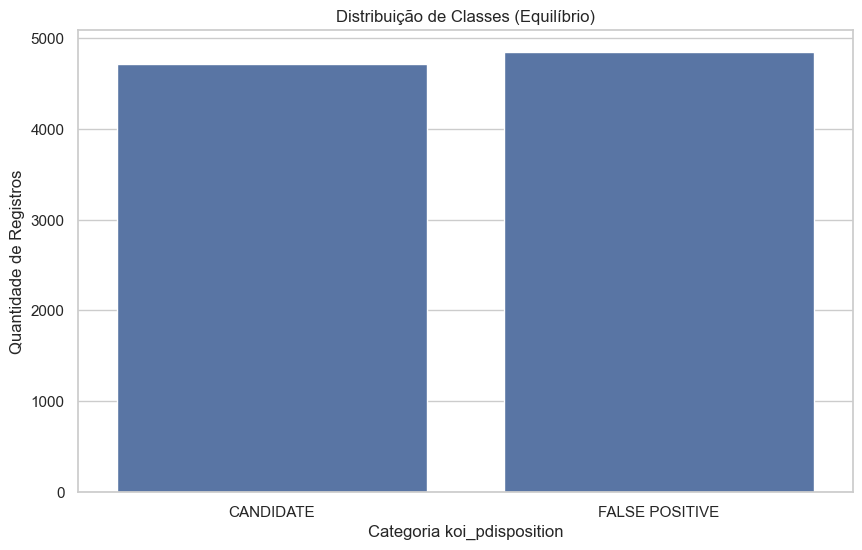

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# quantos registros existem para a categoria da coluna

plt.title('Distribuição de Classes (Equilíbrio)')
sns.countplot(data=koi, x='koi_pdisposition')
plt.xlabel('Categoria koi_pdisposition')
plt.ylabel('Quantidade de Registros')
plt.show()